# Import Libraries

In [72]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

# Read Data

In [75]:
%%time
df = pd.read_csv('CICIDS2018_top_26.csv')

CPU times: total: 5.38 s
Wall time: 6.56 s


In [77]:
df.columns

Index(['Init Fwd Win Byts', 'Init Bwd Win Byts', 'Flow IAT Std',
       'Fwd Seg Size Min', 'Dst Port', 'Fwd Header Len', 'Bwd Header Len',
       'Fwd Act Data Pkts', 'Flow IAT Max', 'Flow IAT Mean', 'Fwd Pkts/s',
       'Flow Pkts/s', 'TotLen Bwd Pkts', 'Pkt Len Max', 'Bwd IAT Mean',
       'RST Flag Cnt', 'ECE Flag Cnt', 'Flow Duration', 'Fwd Pkt Len Max',
       'TotLen Fwd Pkts', 'Active Mean', 'Down/Up Ratio', 'Fwd URG Flags',
       'Protocol', 'Flow Byts/s', 'Label'],
      dtype='object')

# Model Training

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [82]:
X = df.drop(columns=['Label'])
y = df['Label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

### Handling Class Imbalance (SMOTE) 

In [85]:
%%time
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42, k_neighbors=3)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

CPU times: total: 1min 18s
Wall time: 22.7 s


### Train the Model

In [87]:
%%time
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='mlogloss',
)

xgb.fit(X_train_resampled, y_train_resampled);

CPU times: total: 12min 55s
Wall time: 1min 44s


#### Evaluate Models

In [91]:
for name, model in [('XGBoost 26 features', xgb)]:
    y_pred = model.predict(X_test)
    print(f"\n{'='*40}")
    print(f"{name}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


XGBoost 26 features
                          precision    recall  f1-score   support

                  Benign       0.79      0.72      0.76     20000
                     Bot       1.00      1.00      1.00     20000
        Brute Force -Web       0.34      0.95      0.50       111
        Brute Force -XSS       0.98      0.93      0.95        45
        DDOS attack-HOIC       1.00      1.00      1.00     20000
    DDOS attack-LOIC-UDP       0.95      1.00      0.98       346
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00     20000
   DoS attacks-GoldenEye       1.00      1.00      1.00      8281
        DoS attacks-Hulk       1.00      1.00      1.00     20000
DoS attacks-SlowHTTPTest       0.27      0.27      0.27        11
   DoS attacks-Slowloris       1.00      1.00      1.00      1982
          FTP-BruteForce       0.27      0.27      0.27        11
           Infilteration       0.75      0.81      0.78     20000
           SQL Injection       0.61      0.82      0.7

#### Confusion Matrix

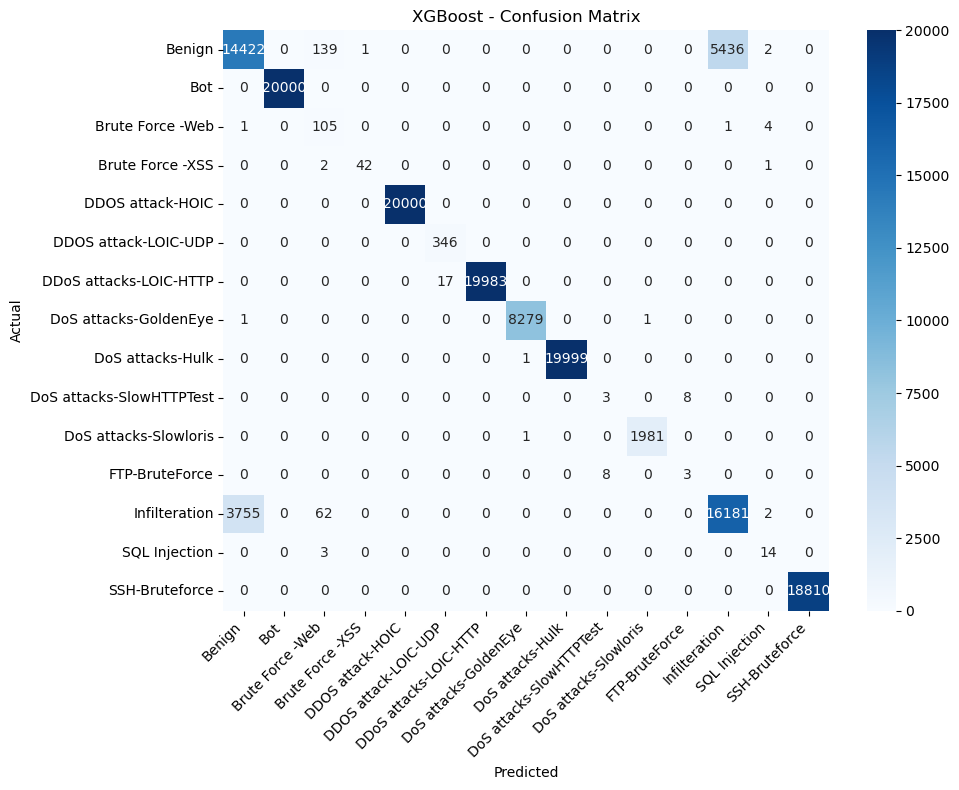

In [94]:
plt.figure(figsize=(10, 8))

cm = confusion_matrix(y_test, xgb.predict(X_test))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')

plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Hyperparameter Tuning

In [97]:
from sklearn.model_selection import RandomizedSearchCV
import time

### Define Search Space

In [100]:
param_dist = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [3, 6, 9],
    'learning_rate'     : [0.01, 0.1, 0.3],
    'subsample'         : [0.7, 0.8, 1.0],
    'colsample_bytree'  : [0.7, 0.8, 1.0],
    'gamma'             : [0, 0.1, 0.2]
}

### RandomizedSearch

In [103]:
xgb_base = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

start = time.time()
xgb_search.fit(X_train_resampled, y_train_resampled)
elapsed = (time.time() - start) / 60

print(f"Done in {elapsed:.1f} minutes")
print(f"Best params: {xgb_search.best_params_}")
print(f"Best macro F1 (CV): {xgb_search.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Done in 144.6 minutes
Best params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}
Best macro F1 (CV): 0.9159


### Evaluate Tuned Model

In [105]:
best_xgb = xgb_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)

print(classification_report(
    y_test, y_pred_tuned,
    target_names=le.classes_
))

                          precision    recall  f1-score   support

                  Benign       0.80      0.74      0.77     20000
                     Bot       1.00      1.00      1.00     20000
        Brute Force -Web       0.34      0.95      0.50       111
        Brute Force -XSS       0.98      0.93      0.95        45
        DDOS attack-HOIC       1.00      1.00      1.00     20000
    DDOS attack-LOIC-UDP       0.96      1.00      0.98       346
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00     20000
   DoS attacks-GoldenEye       1.00      1.00      1.00      8281
        DoS attacks-Hulk       1.00      1.00      1.00     20000
DoS attacks-SlowHTTPTest       0.27      0.27      0.27        11
   DoS attacks-Slowloris       1.00      1.00      1.00      1982
          FTP-BruteForce       0.27      0.27      0.27        11
           Infilteration       0.76      0.81      0.78     20000
           SQL Injection       0.63      0.71      0.67        17
         

### Confusion Matrix after RandomizedSearch

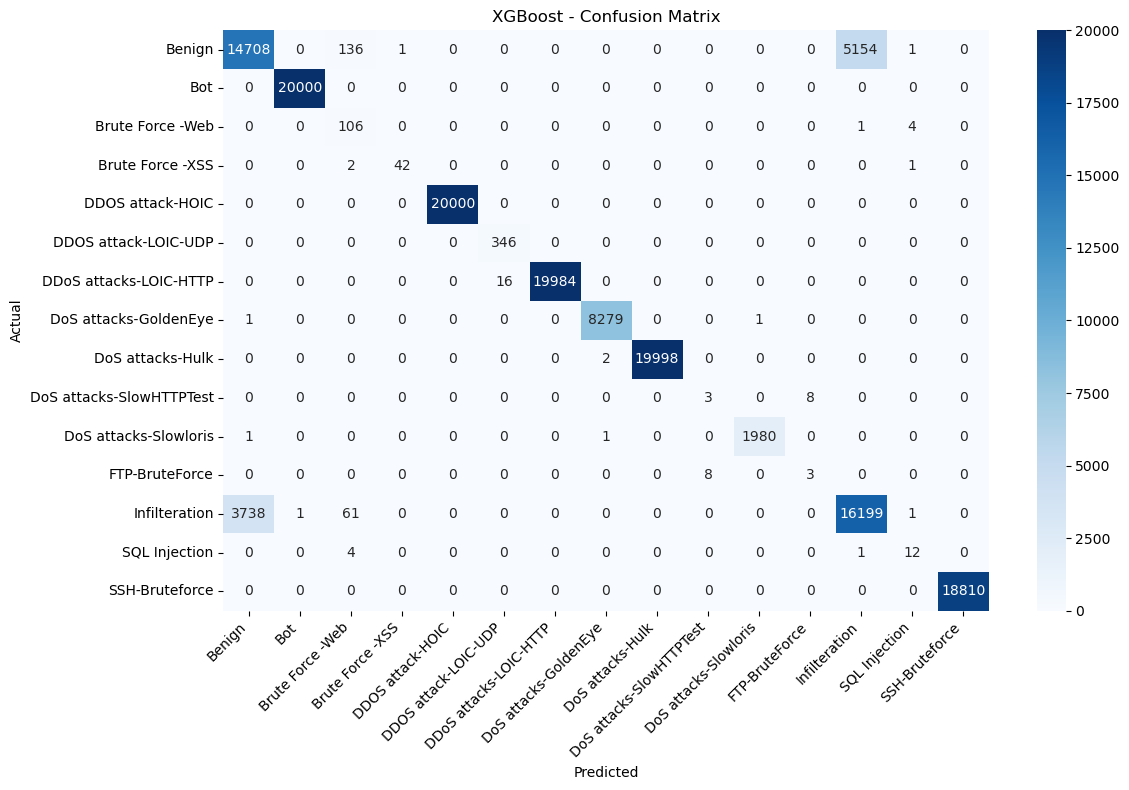

In [111]:
plt.figure(figsize=(12, 8))

cm = confusion_matrix(y_test, best_xgb.predict(X_test))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')

plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('XGB_Confusion_Matrix.png', dpi=400)
plt.show()

### Save the model

In [108]:
import pickle

with open('XGB_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

print("XGB Model saved.")

XGB Model saved.


### Save the Label encoder for XGBoost

In [114]:
with open('XGB_label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("XGB Label Encoder saved.")

XGB Label Encoder saved.


### Test the model on real world data

In [1]:
import joblib
from tensorflow.keras.models import load_model

# Load real dataset
df_real = pd.read_csv('CICIDS2018_10Percent.csv')

# Clean column names from leading/trailing spaces)
df_real.columns = df_real.columns.str.strip()


# Select the same 26 columns used in training
selected_columns = ['Init Fwd Win Byts', 'Init Bwd Win Byts', 'Flow IAT Std',
       'Fwd Seg Size Min', 'Dst Port', 'Fwd Header Len', 'Bwd Header Len',
       'Fwd Act Data Pkts', 'Flow IAT Max', 'Flow IAT Mean', 'Fwd Pkts/s',
       'Flow Pkts/s', 'TotLen Bwd Pkts', 'Pkt Len Max', 'Bwd IAT Mean',
       'RST Flag Cnt', 'ECE Flag Cnt', 'Flow Duration', 'Fwd Pkt Len Max',
       'TotLen Fwd Pkts', 'Active Mean', 'Down/Up Ratio', 'Fwd URG Flags',
       'Protocol', 'Flow Byts/s', 'Label']

df_real = df_real[selected_columns]

X_real = df_real.drop(columns=['Label'])
y_real_raw = df_real['Label']

print("Real data shape:", X_real.shape)


# Replace infinite values with 0
inf_count = np.isinf(X_real.values).sum()
print("Infinite values found:", inf_count)

X_real = X_real.replace([np.inf, -np.inf], 0)

# Just in case there are also genuine NaNs (not from inf), fill those with 0 too
nan_count = X_real.isna().sum().sum()
print("NaN values found:", nan_count)
X_real = X_real.fillna(0)

print("Real data shape after cleaning:", X_real.shape)
print("Class distribution:\n", y_real_raw.value_counts())

# ========================
# XGBOOST evaluation
# ========================
with open('XGB_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)
with open('XGB_label_encoder.pkl', 'rb') as f:
    xgb_le = pickle.load(f)

y_real_xgb = xgb_le.transform(y_real_raw)
xgb_preds = xgb_model.predict(X_real)

print("\n========== XGBOOST ==========")
print(classification_report(y_real_xgb, xgb_preds, target_names=xgb_le.classes_, zero_division=0))

Real data shape: (1198955, 25)
Infinite values found: 10257
NaN values found: 4515
Real data shape after cleaning: (1198955, 25)
Class distribution:
 Label
Benign                      1063690
DDoS attacks-LOIC-HTTP        57536
DDOS attack-HOIC              19886
DoS attacks-Hulk              14520
Bot                           14454
Infilteration                 14061
SSH-Bruteforce                 9405
DoS attacks-GoldenEye          4141
DoS attacks-Slowloris           991
DDOS attack-LOIC-UDP            173
Brute Force -Web                 56
Brute Force -XSS                 23
SQL Injection                     8
DoS attacks-SlowHTTPTest          6
FTP-BruteForce                    5
Name: count, dtype: int64

========== XGBOOST ==========
                          precision    recall  f1-score   support

                  Benign       1.00      0.73      0.85   1063690
                     Bot       1.00      1.00      1.00     14454
        Brute Force -Web       0.01      0.96   